
# Sentiment Analysis with EDA (Student Project)

## Objective:
Perform sentiment analysis and basic EDA on a small dataset.


In [4]:

import pandas as pd

df = pd.read_csv("C:\\Users\\Harsha\\Desktop\\files\\project\\sentiment_dataset.csv")
df.head()

,text,sentiment
0,Average experience,neutral
1,This product is terrible,negative
2,It is acceptable,neutral
3,Worst experience ever,negative
4,Highly recommend this,positive


## Basic EDA

In [5]:

print("Dataset Info:")
print(df.info())

print("\nSentiment Counts:")
print(df['sentiment'].value_counts())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       200 non-null    object
 1   sentiment  200 non-null    object
dtypes: object(2)
memory usage: 3.3+ KB
None

Sentiment Counts:
sentiment
negative    76
positive    68
neutral     56
Name: count, dtype: int64


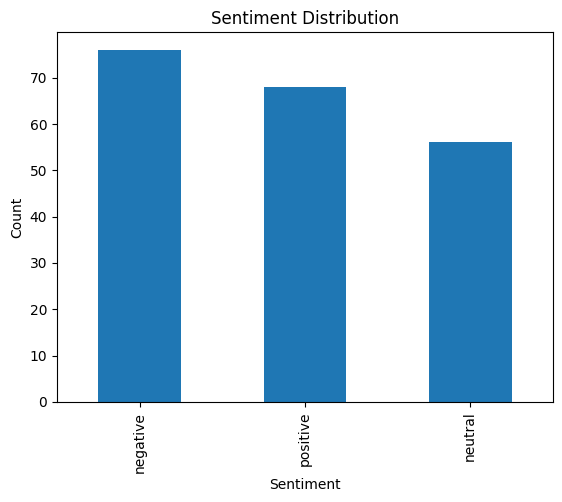

In [6]:

import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


## BERT Prediction

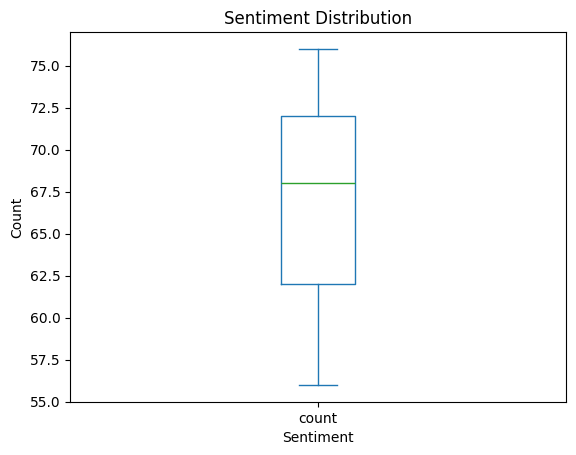

In [7]:
df['sentiment'].value_counts().plot(kind='box')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

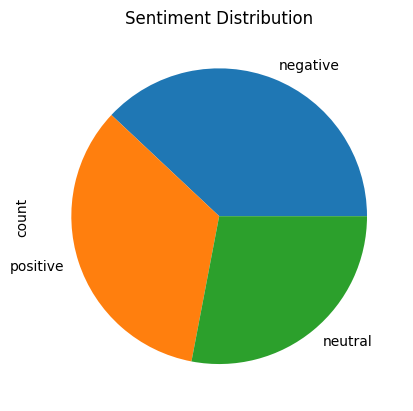

In [8]:
df['sentiment'].value_counts().plot(kind='pie')

plt.title("Sentiment Distribution")


plt.show()

In [9]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

labels = ["Negative", "Positive"]

for text in df['text']:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs).item()

    print(f"{text} → {labels[pred]} ({probs[0][pred]:.4f})")


c:\Users\Harsha\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4189.23it/s]


Average experience → Negative (0.6636)
This product is terrible → Negative (0.9997)
It is acceptable → Positive (0.9997)
Worst experience ever → Negative (0.9998)
Highly recommend this → Positive (0.9999)
Best decision ever → Positive (0.9997)
The app crashes often → Negative (0.9997)
This product is average → Negative (0.9562)
Not worth the money → Negative (0.9998)
I hate this movie → Negative (0.9997)
This product is average → Negative (0.9562)
Great experience overall → Positive (0.9999)
It is acceptable → Positive (0.9997)
The app works perfectly → Positive (0.9999)
I regret buying this → Negative (0.9989)
I regret buying this → Negative (0.9989)
Extremely disappointed → Negative (0.9998)
It works as expected → Positive (0.9992)
Very bad service → Negative (0.9998)
It is decent → Positive (0.9999)
I regret buying this → Negative (0.9989)
Very bad service → Negative (0.9998)
Fantastic service → Positive (0.9999)
The app works perfectly → Positive (0.9999)
Average experience → Negat